# Etapa 1 — Diagnóstico y preparación de los datos

Exploración del archivo

In [1]:
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

RUTA_EXCEL = "../data/raw/Encuesta de Experiencia Comercial DV_concentrado.xlsx"
xls = pd.ExcelFile(RUTA_EXCEL)
xls.sheet_names

['CONTROL DE LLAMADAS', 'Hoja1', 'BASE', 'Hoja2', 'Hoja4']

## 1. Estructura del archivo

El archivo tiene 5 hojas:

- **CONTROL DE LLAMADAS**: bitácora de la encuesta telefónica (una fila por intento de llamada a una distribuidora). Tiene un encabezado "de formulario" a 4 filas (títulos de sección P1–P5 + subpreguntas condicionales)
- **BASE**: padrón de distribuidoras (región, sucursal, coordinador, tipo/nivel, antigüedad, % disponible, etc.)
- **Hoja2**: información de crédito/saldo por distribuidora (límite, disponible, saldo, bolsa).
- **Hoja4**: listas de valores válidos usadas como listas desplegables en Excel (estatus de llamada, Sí/No) — no son datos, son catálogo
- **Hoja1**: vacía

La llave para relacionar las tres tablas de datos es `id_cliente` (en CONTROL DE LLAMADAS aparece como "Numero Dv").

In [2]:
raw = pd.read_excel(RUTA_EXCEL, sheet_name="CONTROL DE LLAMADAS", header=None)
raw.head(6)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,Nombre de Encuestador:,NaN,JUAN FELIPE RAMIREZ LARRIVA,NaN,NaN,NaN,NaN,P1 – Motivo principal,P2 – Calificación,Lógica condicional (IMPORTANTE),NaN,P3 – Competencia,NaN,P4 – Reactivación,P5 – Disposición Final,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pregunta:,Pregunta:,Si responde:,NaN,Pregunta:,Si responde “Sí” → activar pregunta:,Pregunta:,NaN,NaN,NaN
2,Fila,Fecha de llamada,Estatus de CONTACT,Plaza,Numero Dv,Nombre Dv,fhUltimoCanje,"“En una palabra o frase corta, ¿cuál es la pri...","“Del 1 al 5 donde 5 es muy buena y 1 es mala, ...","1, 2 o 3 → ir a sección “Área de Mejora” como ...",4 o 5 → ir a sección “Fortaleza”,“¿Actualmente trabajas con otra financiera?”,“¿Qué es lo que más te gusta de trabajar con e...,¿Qué Necesitas para ser exclusiva de CRECE CON...,“Si logramos resolver el punto que nos comenta...,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,“¿Qué podríamos mejorar?”,“¿Qué es lo que más valoras del servicio?”,NaN,NaN,NaN,Si,Tal vez,No
4,1,2026-02-20 00:00:00,No contestó,ACAYUCAN,86079,MARIA DE LOS ANGELES MEZA REYES,2026-01-30 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2,2026-02-20 00:00:00,No contestó,ACAYUCAN,86166,GABRIELA SANCHEZ GONZALEZ,2026-01-29 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Carga y limpieza de la encuesta (CONTROL DE LLAMADAS)

Se descartan las primeras 4 filas (encabezados de formulario) y se asignan nombres de columna explícitos según el mapeo de preguntas:

- P1 — Motivo principal (texto abierto): por qué no está colocando.
- P2 — Calificación (1–5) + condicional: si 1-3 → área de mejora; si 4-5 → fortaleza.
- P3 — Competencia: ¿trabaja con otra financiera? (Sí/No) + qué le gusta de ellos.
- P4 — Reactivación: qué necesita para ser exclusiva de CRECE CON VALES.
- P5 — Disposición final a ser recontactada (Sí / Tal vez / No), codificada en 3 columnas one-hot.

In [3]:
COLUMNAS = [
    "fila", "fecha_llamada", "estatus_contacto", "plaza", "id_cliente", "nombre_dv", "fh_ultimo_canje",
    "p1_motivo", "p2_calificacion", "p2_area_mejora", "p2_fortaleza",
    "p3_competencia", "p3_gusta_competencia", "p4_necesita_exclusiva",
    "p5_si", "p5_talvez", "p5_no",
]

encuesta = pd.read_excel(RUTA_EXCEL, sheet_name="CONTROL DE LLAMADAS", header=None, skiprows=4)
encuesta.columns = COLUMNAS

# Colapsar P5 (one-hot) en una sola columna categórica
def _p5(row):
    if row["p5_si"] == 1:
        return "Si"
    if pd.notna(row["p5_talvez"]):
        return "Tal vez"
    if pd.notna(row["p5_no"]):
        return "No"
    return pd.NA

encuesta["p5_disposicion"] = encuesta.apply(_p5, axis=1)
encuesta = encuesta.drop(columns=["p5_si", "p5_talvez", "p5_no"])

print(encuesta.shape)
encuesta.head()

(377, 15)


,fila,fecha_llamada,estatus_contacto,plaza,id_cliente,nombre_dv,fh_ultimo_canje,p1_motivo,p2_calificacion,p2_area_mejora,p2_fortaleza,p3_competencia,p3_gusta_competencia,p4_necesita_exclusiva,p5_disposicion
0,1.0,2026-02-20,No contestó,ACAYUCAN,86079.0,MARIA DE LOS ANGELES MEZA REYES,2026-01-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
1,2.0,2026-02-20,No contestó,ACAYUCAN,86166.0,GABRIELA SANCHEZ GONZALEZ,2026-01-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
2,3.0,2026-02-20,No contestó,ACAYUCAN,86052.0,MARIA DEL CARMEN CRUZ JIMENEZ,2025-12-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
3,4.0,2026-02-20,No contestó,ACAYUCAN,109938.0,"PEREZ HERNANDEZ , PETRONILA",2026-01-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
4,5.0,2026-02-20,Llamada efectiva (contestó),ACAYUCAN,86237.0,HERLINDA LOPEZ NO,2026-02-01,"falta de apoyo del promotor, no se le da segui...",5.0,NaN,facilidades en el servicio de pagos,NO,NaN,NaN,<NA>


## 3. Calidad de los registros: ¿la llamada se contestó?

La mayoría de los intentos de llamada **no llegaron a generar una respuesta de encuesta**. Sólo las filas con `estatus_contacto == "Llamada efectiva (contestó)"` tienen datos de encuesta utilizables

,n,%
estatus_contacto,,
Buzón,142,37.7
No contestó,140,37.1
Llamada efectiva (contestó),64,17.0
Se negó a contestar,16,4.2
Reagendar llamada,11,2.9
NaN,3,0.8
Número cambiado,1,0.3


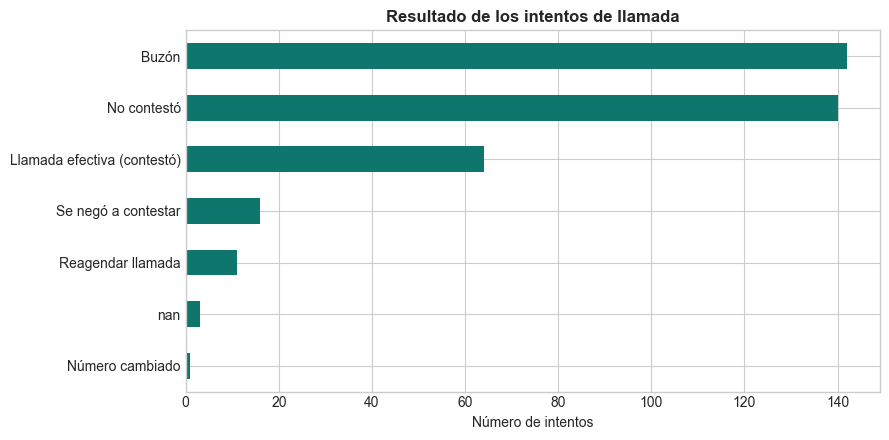

In [15]:
import matplotlib.pyplot as plt

conteo_estatus = encuesta["estatus_contacto"].value_counts(dropna=False)
porcentaje_estatus = (conteo_estatus / len(encuesta) * 100).round(1)
display(pd.DataFrame({"n": conteo_estatus, "%": porcentaje_estatus}))

fig, ax = plt.subplots(figsize=(9, 4.5))
conteo_estatus.sort_values(ascending=True).plot.barh(ax=ax, color="#0f766e")
ax.set_title("Resultado de los intentos de llamada", fontweight="bold")
ax.set_xlabel("Número de intentos")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [5]:
efectivas = encuesta[encuesta["estatus_contacto"] == "Llamada efectiva (contestó)"].copy()
print(f"Llamadas efectivas: {len(efectivas)} de {len(encuesta)} intentos ({len(efectivas)/len(encuesta)*100:.1f}%)")

# % de nulos dentro de las llamadas SI efectivas 
cols_encuesta = ["p1_motivo", "p2_calificacion", "p3_competencia", "p4_necesita_exclusiva", "p5_disposicion"]
(efectivas[cols_encuesta].isna().mean() * 100).round(1).rename("% nulos en llamadas efectivas")

Llamadas efectivas: 64 de 377 intentos (17.0%)


p1_motivo                 1.6
p2_calificacion           1.6
p3_competencia            4.7
p4_necesita_exclusiva    14.1
p5_disposicion           43.8
Name: % nulos en llamadas efectivas, dtype: float64

`p4_necesita_exclusiva` y `p5_disposicion` son condicionales (sólo aplican si la distribuidora dijo trabajar con la competencia / si se resolvió su queja), así que un % de nulos más alto ahí es esperado por cómo está hecho el cuestionario

## 4. Duplicados y llaves

In [6]:
dup = encuesta[encuesta.duplicated(subset="id_cliente", keep=False)].sort_values("id_cliente")
print(f"id_cliente duplicados: {encuesta['id_cliente'].duplicated().sum()}")
dup[["fila", "id_cliente", "nombre_dv", "estatus_contacto", "fecha_llamada"]]

id_cliente duplicados: 7


,fila,id_cliente,nombre_dv,estatus_contacto,fecha_llamada
215,528.0,104739.0,DE LOERA DUEÑAS MARTIN,No contestó,2026-02-21
218,528.0,104739.0,DE LOERA DUEÑAS MARTIN,Buzón,2026-02-21
217,527.0,105180.0,ROSALES ROSALES FERNANDO,Buzón,2026-02-21
214,527.0,105180.0,ROSALES ROSALES FERNANDO,No contestó,2026-02-21
216,526.0,108179.0,"MONTELONGO DE LA CRUZ , FABIOLA",No contestó,2026-02-21
213,526.0,108179.0,"MONTELONGO DE LA CRUZ , FABIOLA",Buzón,2026-02-21
170,482.0,110799.0,"DELGADO MORALES , MA GUADALUPE",No contestó,2026-02-21
168,482.0,110799.0,"DELGADO MORALES , MA GUADALUPE",No contestó,2026-02-21
167,481.0,112899.0,"BOCANEGRA TORRES , MA GUADALUPE",No contestó,2026-02-21
169,481.0,112899.0,"BOCANEGRA TORRES , MA GUADALUPE",No contestó,2026-02-21


## 5. Cruce con BASE (padrón) y Hoja2 (crédito/saldo)

In [7]:
base = pd.read_excel(RUTA_EXCEL, sheet_name="BASE")
hoja2 = pd.read_excel(RUTA_EXCEL, sheet_name="Hoja2")

print(f"encuesta: {encuesta['id_cliente'].nunique()} id_cliente únicos")
print(f"BASE:     {base['id_cliente'].nunique()} id_cliente únicos")
print(f"Hoja2:    {hoja2['id_cliente'].nunique()} id_cliente únicos")
print()
print(f"% ids de encuesta encontrados en BASE:  {encuesta['id_cliente'].isin(base['id_cliente']).mean()*100:.1f}%")
print(f"% ids de encuesta encontrados en Hoja2: {encuesta['id_cliente'].isin(hoja2['id_cliente']).mean()*100:.1f}%")

encuesta: 369 id_cliente únicos
BASE:     1915 id_cliente únicos
Hoja2:    2158 id_cliente únicos

% ids de encuesta encontrados en BASE:  99.2%
% ids de encuesta encontrados en Hoja2: 99.2%


In [8]:
base_cols = ["id_cliente", "region", "TIPO", "tipo.antiguedad", "%disponible", "tipo_colocado"]
hoja2_cols = ["id_cliente", "limite", "DISPONIBLE", "SALDO", "Bolsa", "Disponible_Bolsa"]

dataset = (
    encuesta
    .merge(base[base_cols].drop_duplicates("id_cliente"), on="id_cliente", how="left")
    .merge(hoja2[hoja2_cols].drop_duplicates("id_cliente"), on="id_cliente", how="left")
)
dataset.shape

(377, 25)

## 6. Criterio de inclusión propuesto

Para el análisis de contenido de la encuesta (P1–P5), se propone **incluir únicamente los registros con `estatus_contacto == "Llamada efectiva (contestó)"`**, ya que son los únicos con respuestas reales de la distribuidora. El resto (Buzón, No contestó, Se negó a contestar, Reagendar, Número cambiado) se documenta como parte de la tasa de contacto/respuesta, pero se excluye del análisis de contenido por no tener información que analizar.

El dataset completo (`dataset`, con variables de BASE/Hoja2) sí se conserva para todas las filas, por si se quiere caracterizar diferencias entre quién contesta y quién no (p. ej. por región, tipo, antigüedad, % disponible).

In [9]:
dataset_encuestados = dataset[dataset["estatus_contacto"] == "Llamada efectiva (contestó)"].copy()

import os
os.makedirs("../data/processed", exist_ok=True)
dataset.to_csv("../data/processed/dataset_completo.csv", index=False)
dataset_encuestados.to_csv("../data/processed/dataset_encuestados.csv", index=False)

with pd.ExcelWriter("../data/processed/base_encuestas_procesada.xlsx", engine="openpyxl") as writer:
    dataset.to_excel(writer, sheet_name="LLAMADAS_COMPLETAS", index=False)
    dataset_encuestados.to_excel(writer, sheet_name="ENCUESTAS_EFECTIVAS", index=False)

print(f"Guardado: dataset_completo.csv ({len(dataset)} filas)")
print(f"Guardado: dataset_encuestados.csv ({len(dataset_encuestados)} filas)")
print("Guardado: base_encuestas_procesada.xlsx")

Guardado: dataset_completo.csv (377 filas)
Guardado: dataset_encuestados.csv (64 filas)
Guardado: base_encuestas_procesada.xlsx


## 7. Análisis exploratorio de respuestas efectivas

Se revisan primero la calidad de las 64 respuestas y las variables cerradas. Las respuestas abiertas quedan organizadas para una clasificación temática posterior.

In [10]:
efectivas = dataset_encuestados.copy()

# Validar que no haya más de una respuesta efectiva por distribuidora.
ids_validos = efectivas["id_cliente"].notna()
duplicados_efectivas = efectivas.loc[
    ids_validos & efectivas.duplicated("id_cliente", keep=False)
].sort_values("id_cliente")

print(f"Respuestas efectivas: {len(efectivas)}")
print(f"Distribuidoras únicas con respuesta efectiva: {efectivas.loc[ids_validos, 'id_cliente'].nunique()}")
print(f"Registros efectivos con id_cliente duplicado: {len(duplicados_efectivas)}")

# Faltantes en las preguntas de la encuesta.
resumen_faltantes = (
    efectivas[cols_encuesta]
    .isna()
    .agg(["sum", "mean"])
    .T
    .rename(columns={"sum": "n_faltantes", "mean": "proporcion_faltante"})
)
resumen_faltantes["porcentaje_faltante"] = (resumen_faltantes["proporcion_faltante"] * 100).round(1)
display(resumen_faltantes[["n_faltantes", "porcentaje_faltante"]])

# Normalizar las respuestas de competencia para evitar contar variantes como categorías distintas.
def normalizar_competencia(valor):
    if pd.isna(valor):
        return pd.NA
    respuesta = str(valor).strip().lower()
    if respuesta in {"si", "sí"}:
        return "Si"
    if respuesta == "no":
        return "No"
    return "Revisar"

efectivas["p3_competencia_limpia"] = efectivas["p3_competencia"].map(normalizar_competencia)

# Distribución de las preguntas cerradas.
for columna in ["p2_calificacion", "p3_competencia_limpia", "p5_disposicion"]:
    print(f"\n{columna}")
    tabla = efectivas[columna].value_counts(dropna=False).rename_axis("respuesta").reset_index(name="n")
    tabla["porcentaje"] = (tabla["n"] / len(efectivas) * 100).round(1)
    display(tabla)

# Respuestas abiertas listas para lectura y clasificación temática.
respuestas_abiertas = efectivas[
    ["id_cliente", "nombre_dv", "p1_motivo", "p2_area_mejora", "p2_fortaleza", "p3_gusta_competencia", "p4_necesita_exclusiva"]
].sort_values("id_cliente")
display(respuestas_abiertas)

Respuestas efectivas: 64
Distribuidoras únicas con respuesta efectiva: 64
Registros efectivos con id_cliente duplicado: 0


,n_faltantes,porcentaje_faltante
p1_motivo,1.0,1.6
p2_calificacion,1.0,1.6
p3_competencia,3.0,4.7
p4_necesita_exclusiva,9.0,14.1
p5_disposicion,28.0,43.8



p2_calificacion


,respuesta,n,porcentaje
0,5.0,37,57.8
1,4.0,10,15.6
2,3.0,8,12.5
3,2.0,6,9.4
4,1.0,2,3.1
5,NaN,1,1.6



p3_competencia_limpia


,respuesta,n,porcentaje
0,Si,54,84.4
1,No,6,9.4
2,<NA>,3,4.7
3,Revisar,1,1.6



p5_disposicion


,respuesta,n,porcentaje
0,<NA>,28,43.8
1,Si,26,40.6
2,Tal vez,6,9.4
3,No,4,6.2


,id_cliente,nombre_dv,p1_motivo,p2_area_mejora,p2_fortaleza,p3_gusta_competencia,p4_necesita_exclusiva
192,36033.0,MARIA DE LOS ANGELES CLAUDIA HERNANDEZ ALVARADO,NO TIENE APOYO DE PARTE DE GESTORIA,NaN,PRESTAMOS PERSONALES,"PUNTOS, BONIFICACIONES 15,16 Y 17",MAS APOYO EN COBRANZA Y MAS DIAS DE PAGAR
186,36062.0,CLAUDIA BEATRIZ MURILLO GARCIA,"NO TIENE CRECIMIENTO, NO REGALOS",CAMBIAR LOS GERENTES,NaN,"COMPENSACIONES, DIGITAL, ASESORIA",NADA
198,36188.0,MAYELA DEL CARMEN GARCIA,SE TRASO CON PAGOS,NaN,TODO ESTA BIEN,TIEMPO RESPECTO A LOS PAGOS,MAS TIEMPO PARA PAGAR SUS RELACIONES
193,36205.0,JOSE JAVIER GARCIA MORENO,no hay clientes,NaN,PRESTAMOS PERSONALES,trasferencia de pago,TRASFERENCIA DE PAGO
191,40061.0,GENOVEVA TORRES PARGA,YA VA A CERRAR CON LA FINANCIERA,MAS APOYO EN GESTORIA,NaN,APOYO CON GESTORIA,NO QUIERE TRABAJAR MAS
...,...,...,...,...,...,...,...
264,116044.0,"OLIVAS LEYVA , BERTHA ORALIA",por que no le gusto la atencion,atencion al clientre,NaN,la atencion al cliente,no quiere trabajar mas aquí
221,116555.0,"HEREDIA RODRIGUEZ , IRMA ANGELICA",no le gusta el porcentaje y dias de pago,NaN,el personal es amable,la bonificacion y dias pago,que mejoraran las bonificaciones
78,116732.0,"ESPITIA SANTOS , SANDY",esta esperando jalar a sus clientes de otra fi...,NaN,el interes,hay mas facilidades en general,es su proposito y su meta
72,117047.0,"CALIX GOMEZ , YENI",no se quiere arriesgar con nuevos clientes,NaN,la amabilidad y la atencion,tienen mejor facilidades,tener mejor credito en la financiera


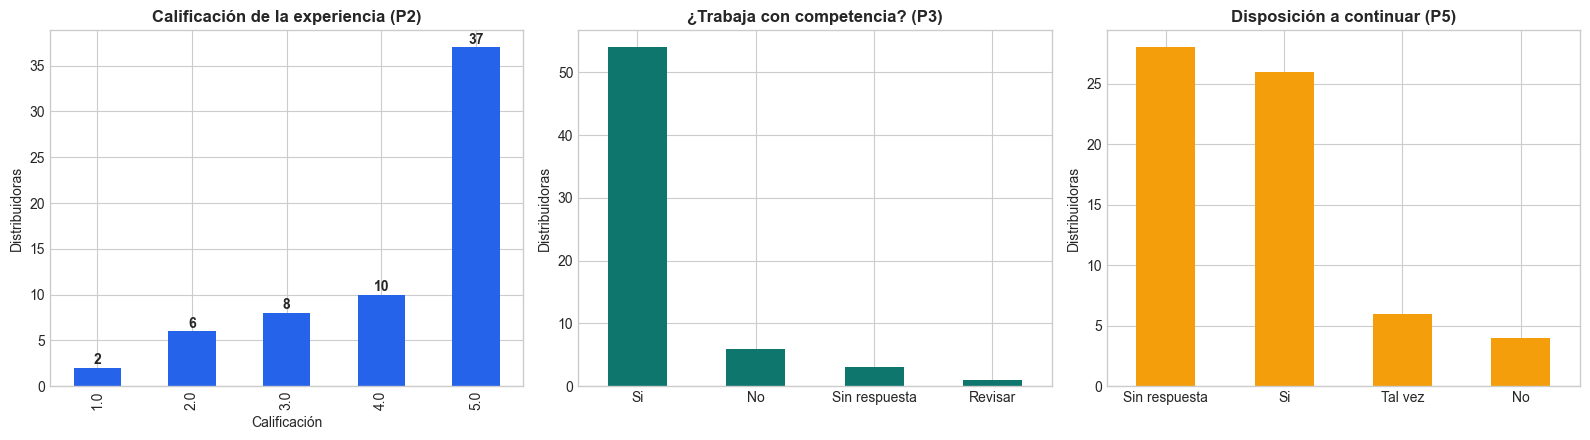

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

calificaciones = efectivas["p2_calificacion"].dropna().value_counts().sort_index()
calificaciones.plot.bar(ax=axes[0], color="#2563eb")
axes[0].set_title("Calificación de la experiencia (P2)", fontweight="bold")
axes[0].set_xlabel("Calificación")
axes[0].set_ylabel("Distribuidoras")
for indice, valor in enumerate(calificaciones):
    axes[0].text(indice, valor + 0.4, str(valor), ha="center", fontweight="bold")

competencia = efectivas["p3_competencia_limpia"].value_counts(dropna=False).rename(index={pd.NA: "Sin respuesta"})
disposicion = efectivas["p5_disposicion"].value_counts(dropna=False).rename(index={pd.NA: "Sin respuesta"})
competencia.plot.bar(ax=axes[1], color="#0f766e")
axes[1].set_title("¿Trabaja con competencia? (P3)", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Distribuidoras")
axes[1].tick_params(axis="x", rotation=0)

disposicion.plot.bar(ax=axes[2], color="#f59e0b")
axes[2].set_title("Disposición a continuar (P5)", fontweight="bold")
axes[2].set_xlabel("")
axes[2].set_ylabel("Distribuidoras")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 8. Clasificación temática inicial

La clasificación usa palabras clave como primer borrador. Una respuesta puede tener más de un tema y los casos no reconocidos quedan marcados para revisión manual.

In [11]:
import re

TEMAS = {
    "Pagos y condiciones financieras": [
        "pago", "pagos", "dias", "días", "porcentaje", "interes", "interés",
        "credito", "crédito", "saldo", "prestamo", "préstamo"
    ],
    "Atencion, gestoría y cobranza": [
        "atencion", "atención", "servicio", "personal", "gerente", "gestoria",
        "gestoría", "cobranza", "cobro", "apoyo"
    ],
    "Beneficios e incentivos": [
        "regalo", "regalos", "premio", "puntos", "bonificacion", "bonificación",
        "compensacion", "compensación", "beneficio"
    ],
    "Producto digital": ["digital", "vales digitales", "vale digital"],
    "Clientes y colocacion": [
        "cliente", "clientes", "crecimiento", "colocar", "colocacion", "colocación",
        "ventas"
    ],
    "Salida o desinteres": [
        "cerrar", "no quiere", "dejar", "trabajar mas", "trabajar más", "ya no"
    ],
}


def normalizar_texto(valor):
    if pd.isna(valor):
        return ""
    texto = str(valor).lower()
    return re.sub(r"\s+", " ", texto).strip()


def clasificar_temas(valor):
    texto = normalizar_texto(valor)
    if not texto:
        return ["Sin respuesta"]
    temas = [
        tema
        for tema, palabras in TEMAS.items()
        if any(re.search(r"\b" + re.escape(palabra) + r"\b", texto) for palabra in palabras)
    ]
    return temas or ["Otros / revisar"]

respuestas_tematizadas = respuestas_abiertas.copy()
respuestas_tematizadas["temas_p1"] = respuestas_tematizadas["p1_motivo"].apply(clasificar_temas)
respuestas_tematizadas["temas_p4"] = respuestas_tematizadas["p4_necesita_exclusiva"].apply(clasificar_temas)

print("Temas en P1: motivos para no colocar")
conteo_p1 = respuestas_tematizadas["temas_p1"].explode().value_counts().rename_axis("tema").reset_index(name="n")
conteo_p1["porcentaje"] = (conteo_p1["n"] / len(respuestas_tematizadas) * 100).round(1)
display(conteo_p1)

print("Temas en P4: necesidades para trabajar en exclusiva")
conteo_p4 = respuestas_tematizadas["temas_p4"].explode().value_counts().rename_axis("tema").reset_index(name="n")
conteo_p4["porcentaje"] = (conteo_p4["n"] / len(respuestas_tematizadas) * 100).round(1)
display(conteo_p4)

# Casos que necesitan revisión manual antes de sacar conclusiones.
casos_revision = respuestas_tematizadas[
    respuestas_tematizadas["temas_p1"].apply(lambda temas: "Otros / revisar" in temas)
    | respuestas_tematizadas["temas_p4"].apply(lambda temas: "Otros / revisar" in temas)
]
display(casos_revision[["id_cliente", "p1_motivo", "p4_necesita_exclusiva", "temas_p1", "temas_p4"]])

# Guardar el borrador temático sin reemplazar la base original.
respuestas_tematizadas_export = respuestas_tematizadas.copy()
respuestas_tematizadas_export["temas_p1"] = respuestas_tematizadas_export["temas_p1"].apply(lambda temas: "; ".join(temas))
respuestas_tematizadas_export["temas_p4"] = respuestas_tematizadas_export["temas_p4"].apply(lambda temas: "; ".join(temas))
respuestas_tematizadas_export.to_csv("../data/processed/respuestas_tematizadas_borrador.csv", index=False)
print("Guardado: respuestas_tematizadas_borrador.csv")

Temas en P1: motivos para no colocar


,tema,n,porcentaje
0,Clientes y colocacion,32,50.0
1,Otros / revisar,14,21.9
2,Pagos y condiciones financieras,7,10.9
3,"Atencion, gestoría y cobranza",6,9.4
4,Salida o desinteres,5,7.8
5,Producto digital,2,3.1
6,Beneficios e incentivos,1,1.6
7,Sin respuesta,1,1.6


Temas en P4: necesidades para trabajar en exclusiva


,tema,n,porcentaje
0,Otros / revisar,36,56.2
1,Sin respuesta,9,14.1
2,Clientes y colocacion,7,10.9
3,"Atencion, gestoría y cobranza",6,9.4
4,Pagos y condiciones financieras,5,7.8
5,Salida o desinteres,2,3.1
6,Producto digital,2,3.1


,id_cliente,p1_motivo,p4_necesita_exclusiva,temas_p1,temas_p4
186,36062.0,"NO TIENE CRECIMIENTO, NO REGALOS",NADA,"[Beneficios e incentivos, Clientes y colocacion]",[Otros / revisar]
198,36188.0,SE TRASO CON PAGOS,MAS TIEMPO PARA PAGAR SUS RELACIONES,[Pagos y condiciones financieras],[Otros / revisar]
31,57290.0,Ya tiene una lista de clientes fieles y no se ...,perder el miedo a que no le paguen,[Clientes y colocacion],[Otros / revisar]
36,57299.0,no ha tenido clientes,que le presten dinero,[Clientes y colocacion],[Otros / revisar]
38,57345.0,tiene cuidado y no da vales a cualquiera ya ti...,no le interesa,[Clientes y colocacion],[Otros / revisar]
327,62187.0,No ha tenido clientes,Más tiempo para pagar después de la quincena,[Clientes y colocacion],[Otros / revisar]
325,62319.0,No ha tenido clientes,Está todo bien,[Clientes y colocacion],[Otros / revisar]
336,62322.0,No ha tenido clientes,A ella le gusta trabajar con todas sus financi...,[Clientes y colocacion],[Otros / revisar]
67,77020.0,esta pasando por problemas de salud,que la fiananciera baje sus intereses,[Otros / revisar],[Otros / revisar]
102,77215.0,no le quiere dar vale a cualquiera,buscar mas clientes,[Otros / revisar],[Clientes y colocacion]


Guardado: respuestas_tematizadas_borrador.csv


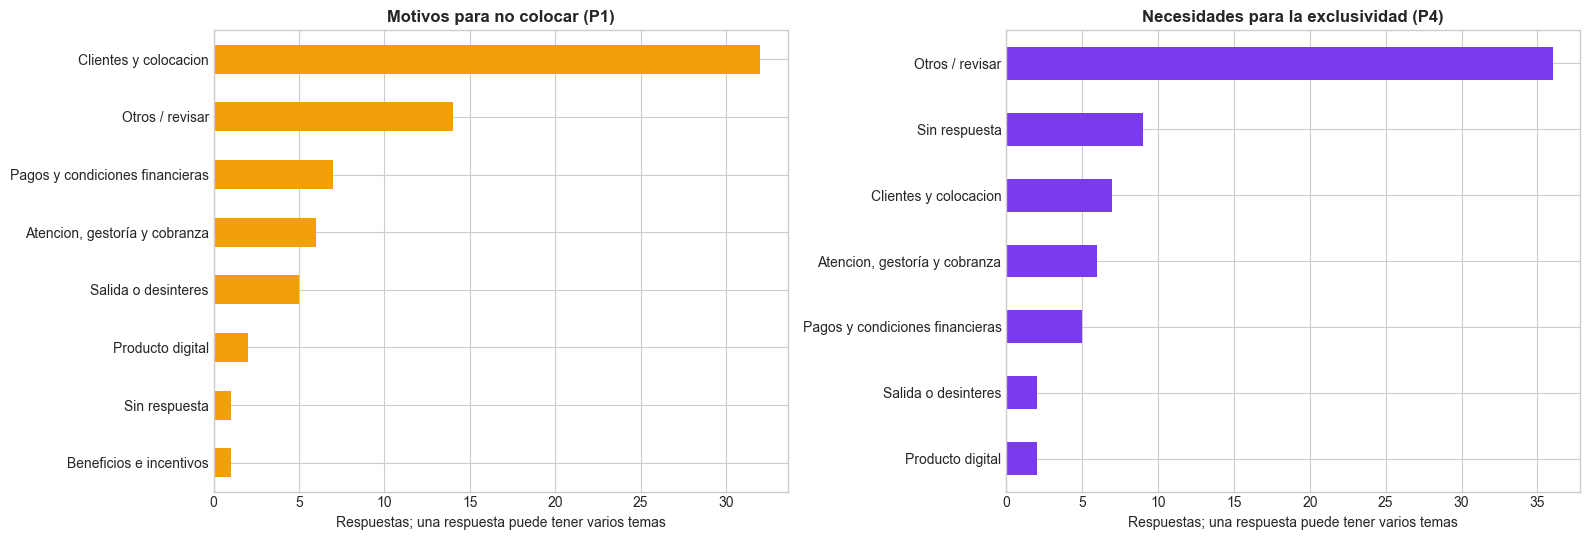

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

conteo_p1.sort_values("n").plot.barh(
    x="tema", y="n", ax=axes[0], legend=False, color="#f59e0b"
)
axes[0].set_title("Motivos para no colocar (P1)", fontweight="bold")
axes[0].set_xlabel("Respuestas; una respuesta puede tener varios temas")
axes[0].set_ylabel("")

conteo_p4.sort_values("n").plot.barh(
    x="tema", y="n", ax=axes[1], legend=False, color="#7c3aed"
)
axes[1].set_title("Necesidades para la exclusividad (P4)", fontweight="bold")
axes[1].set_xlabel("Respuestas; una respuesta puede tener varios temas")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 9. Exploración NLP de temas

Se aplica TF-IDF y NMF para descubrir agrupaciones de palabras en las respuestas abiertas. Los temas son exploratorios y deben validarse leyendo sus ejemplos.

In [12]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer

STOP_ES = [
    "a", "al", "algo", "con", "como", "de", "del", "el", "ella", "en",
    "es", "esta", "este", "la", "las", "le", "los", "mas", "más", "no",
    "para", "por", "que", "se", "su", "sus", "tiene", "un", "una", "y"
]


def ejecutar_nmf(serie, nombre, n_topics=3):
    textos = serie.fillna("").astype(str)
    validos = textos.str.strip().ne("")
    textos_validos = textos[validos]

    vectorizador = TfidfVectorizer(
        lowercase=True,
        stop_words=STOP_ES,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
    )
    matriz = vectorizador.fit_transform(textos_validos)
    n_topics_real = min(n_topics, matriz.shape[0], matriz.shape[1])
    modelo = NMF(n_components=n_topics_real, init="nndsvda", random_state=42, max_iter=500)
    matriz_temas = modelo.fit_transform(matriz)

    print(f"\n{nombre}: {len(textos_validos)} respuestas analizadas")
    for numero, componentes in enumerate(modelo.components_, start=1):
        palabras = vectorizador.get_feature_names_out()[componentes.argsort()[-8:][::-1]]
        print(f"Tema {numero}: {', '.join(palabras)}")

    asignaciones = pd.DataFrame({
        "indice": textos_validos.index,
        "tema_nlp": matriz_temas.argmax(axis=1) + 1,
        "confianza_relativa": matriz_temas.max(axis=1).round(3),
        "texto": textos_validos.values,
    })
    print("Distribución de respuestas por tema:")
    display(asignaciones["tema_nlp"].value_counts().sort_index().rename_axis("tema_nlp").reset_index(name="n"))

    print("Ejemplos representativos por tema:")
    for tema in sorted(asignaciones["tema_nlp"].unique()):
        print(f"\nTema {tema}")
        display(asignaciones[asignaciones["tema_nlp"] == tema].nlargest(3, "confianza_relativa")[["confianza_relativa", "texto"]])
    return asignaciones

asignaciones_p1 = ejecutar_nmf(efectivas["p1_motivo"], "P1: motivo para no colocar")
asignaciones_p4 = ejecutar_nmf(efectivas["p4_necesita_exclusiva"], "P4: necesidad para trabajar en exclusiva")

respuestas_nlp = respuestas_tematizadas.copy()
respuestas_nlp["tema_nlp_p1"] = asignaciones_p1.set_index("indice")["tema_nlp"]
respuestas_nlp["tema_nlp_p4"] = asignaciones_p4.set_index("indice")["tema_nlp"]
respuestas_nlp.to_csv("../data/processed/respuestas_nlp_borrador.csv", index=False)
print("Guardado: respuestas_nlp_borrador.csv")


P1: motivo para no colocar: 63 respuestas analizadas
Tema 1: clientes, da, falta, hay, crece, confiables, clientes confiables, dice
Tema 2: tenido, ha tenido, ha, tenido clientes, clientes, ocupaciones personales, tenido otras, ocupaciones
Tema 3: quiere, vales, ya, da, cualquiera, problemas, quiere arriesgar, arriesgar
Distribución de respuestas por tema:


,tema_nlp,n
0,1,22
1,2,10
2,3,31


Ejemplos representativos por tema:

Tema 1


,confianza_relativa,texto
11,0.509,tiene clientes selecionados
43,0.509,no tiene clientes
55,0.509,POR QUE NO TIENE CLIENTES



Tema 2


...


Tema 2


,confianza_relativa,texto
11,0.598,no le interesa ser exclusiva
12,0.598,no le interesa ser exclusiva
45,0.598,no le interesa ser exclusiva



Tema 3


,confianza_relativa,texto
6,0.767,buscar clientes responsables
16,0.767,buscar clientes nuevos solo que tiene temor
19,0.767,buscar mas clientes


Guardado: respuestas_nlp_borrador.csv


## 10. Reporte ejecutivo

### Objetivo

Identificar por qué las distribuidoras dejan de colocar, qué elementos valoran de otras financieras y qué condiciones podrían favorecer su reactivación o exclusividad.

### Base analizada

- 377 intentos de llamada registrados.
- 64 llamadas efectivas, equivalentes al 17.0% del total.
- 64 distribuidoras únicas con respuesta efectiva.
- No se encontraron duplicados entre las respuestas efectivas.
- Las respuestas abiertas tienen texto libre, errores ortográficos y algunas respuestas ambiguas; por eso el NLP se utiliza como apoyo exploratorio, no como clasificación definitiva.

### Hallazgos principales

1. La satisfacción declarada es relativamente alta entre quienes respondieron: 47 de 63 calificaciones válidas dieron 4 o 5 (74.6%). Esto convive con una baja colocación, por lo que satisfacción y actividad comercial no deben interpretarse como lo mismo.
2. La falta o dificultad para conseguir clientes aparece como la señal más fuerte en P1. La clasificación inicial la detecta en 32 respuestas (50.0%).
3. La competencia está presente: 54 respuestas se normalizaron como "Sí" y 6 como "No". Un registro requiere revisión por no ser una respuesta cerrada clara.
4. Entre las respuestas válidas de P5, 26 dijeron "Sí", 6 "Tal vez" y 4 "No". Los 28 faltantes corresponden principalmente a la lógica condicional del cuestionario, no necesariamente a rechazo.
5. En P4, las necesidades recurrentes apuntan a mejores condiciones financieras, apoyo operativo y comercial, más clientes confiables y mejoras digitales.

### Resultado del NLP

El modelo TF-IDF + NMF encontró señales exploratorias que coinciden con la lectura del negocio:

- P1: grupos alrededor de clientes/colocación, falta de actividad previa y temor o decisión de no arriesgarse.
- P4: grupos alrededor de condiciones financieras, rechazo a la exclusividad y búsqueda de clientes.

Estos grupos son útiles para ordenar la revisión, pero no deben presentarse como porcentajes finales: con 64 respuestas, textos breves y vocabulario irregular, los temas dependen de la limpieza y del número de componentes elegido.

### Recomendaciones

1. Priorizar una estrategia de recuperación de clientes y acompañamiento comercial.
2. Revisar plazos, fechas de pago, disponibilidad, intereses y comisiones frente a la oferta de la competencia.
3. Reforzar gestoría, cobranza, atención y seguimiento de coordinadores.
4. Evaluar mejoras en la aplicación y opciones digitales.
5. Contactar primero a quienes respondieron "Sí" o "Tal vez" en P5.
6. Validar manualmente los grupos NLP antes de convertirlos en indicadores oficiales.

### Siguiente fase

Crear un catálogo final de temas, asignarlo manualmente con apoyo del NLP y cruzarlo con región, tipo de distribuidora, antigüedad y disponibilidad. Después se puede construir una matriz de segmentos y un listado de acciones de recontacto.

In [17]:
from pathlib import Path

n_intentos = len(encuesta)
n_efectivas = len(efectivas)
calificaciones_validas = efectivas["p2_calificacion"].dropna()
n_calificaciones_altas = (calificaciones_validas >= 4).sum()
competencia_limpia = efectivas["p3_competencia"].map(normalizar_competencia)
competencia_si = (competencia_limpia == "Si").sum()
competencia_no = (competencia_limpia == "No").sum()
competencia_revisar = (competencia_limpia == "Revisar").sum()

reporte = f"""# Reporte ejecutivo: encuesta a distribuidoras

## Objetivo

Identificar por qué las distribuidoras dejan de colocar, qué valoran de otras financieras y qué condiciones podrían favorecer su reactivación o exclusividad.

## Base analizada

- {n_intentos} intentos de llamada.
- {n_efectivas} llamadas efectivas ({n_efectivas / n_intentos * 100:.1f}% del total).
- {efectivas.loc[efectivas['id_cliente'].notna(), 'id_cliente'].nunique()} distribuidoras únicas con respuesta efectiva.
- {len(duplicados_efectivas)} registros efectivos con id_cliente duplicado.

## Hallazgos

- **Satisfacción:** {n_calificaciones_altas} de {len(calificaciones_validas)} calificaciones válidas fueron 4 o 5 ({n_calificaciones_altas / len(calificaciones_validas) * 100:.1f}%). Satisfacción y actividad comercial no son equivalentes.
- **Colocación:** la falta o dificultad para conseguir clientes es la señal más frecuente en P1 y debe ser la primera hipótesis de intervención.
- **Competencia:** {competencia_si} respuestas fueron "Sí", {competencia_no} "No" y {competencia_revisar} requieren revisión por texto no estandarizado.
- **Disposición:** P5 tiene 26 respuestas "Sí", 6 "Tal vez" y 4 "No". Los faltantes son condicionales del cuestionario y no deben contarse automáticamente como rechazo.
- **Necesidades:** P4 concentra señales sobre condiciones financieras, apoyo operativo/comercial, clientes confiables y herramientas digitales.

## NLP exploratorio

Se aplicó TF-IDF + NMF por separado a P1 y P4. Los grupos encontrados apuntan a clientes/colocación, temor o falta de actividad, condiciones financieras, exclusividad y búsqueda de clientes. Son señales exploratorias, no categorías definitivas ni porcentajes oficiales.

## Recomendaciones

1. Priorizar recuperación de clientes y acompañamiento comercial.
2. Revisar plazos, fechas de pago, disponibilidad, intereses y comisiones frente a la competencia.
3. Reforzar gestoría, cobranza, atención y seguimiento de coordinadores.
4. Evaluar mejoras en la aplicación y opciones digitales.
5. Recontactar primero a quienes respondieron "Sí" o "Tal vez" en P5.
6. Validar manualmente los temas NLP antes de usarlos como indicadores.

## Limitaciones

La muestra tiene 64 respuestas, las preguntas abiertas son breves y contienen errores ortográficos y respuestas ambiguas. El reporte describe señales de esta muestra y no permite generalizar a todas las distribuidoras sin una muestra mayor.
"""

ruta_reporte = Path("../data/processed/reporte_ejecutivo_encuestas.md")
ruta_reporte.write_text(reporte, encoding="utf-8")
print(f"Guardado: {ruta_reporte}")
print(reporte)

Guardado: ..\data\processed\reporte_ejecutivo_encuestas.md
# Reporte ejecutivo: encuesta a distribuidoras

## Objetivo

Identificar por qué las distribuidoras dejan de colocar, qué valoran de otras financieras y qué condiciones podrían favorecer su reactivación o exclusividad.

## Base analizada

- 377 intentos de llamada.
- 64 llamadas efectivas (17.0% del total).
- 64 distribuidoras únicas con respuesta efectiva.
- 0 registros efectivos con id_cliente duplicado.

## Hallazgos

- **Satisfacción:** 47 de 63 calificaciones válidas fueron 4 o 5 (74.6%). Satisfacción y actividad comercial no son equivalentes.
- **Colocación:** la falta o dificultad para conseguir clientes es la señal más frecuente en P1 y debe ser la primera hipótesis de intervención.
- **Competencia:** 54 respuestas fueron "Sí", 6 "No" y 1 requieren revisión por texto no estandarizado.
- **Disposición:** P5 tiene 26 respuestas "Sí", 6 "Tal vez" y 4 "No". Los faltantes son condicionales del cuestionario y no deben contars

## 11. Segmentación para recontacto

Se construye una priorización operativa usando únicamente señales observadas en la encuesta. No es un modelo predictivo: sirve para ordenar el seguimiento comercial.

In [13]:
segmentos = efectivas.copy()
segmentos["competencia_limpia"] = segmentos["p3_competencia"].map(normalizar_competencia)
segmentos["tema_nlp_p1"] = asignaciones_p1.set_index("indice")["tema_nlp"]
segmentos["tema_nlp_p4"] = asignaciones_p4.set_index("indice")["tema_nlp"]


def definir_segmento(fila):
    disposicion = fila["p5_disposicion"]
    competencia = fila["competencia_limpia"]
    if pd.notna(disposicion) and disposicion in {"Si", "Tal vez"}:
        if pd.notna(competencia) and competencia == "Si":
            return "Recontacto prioritario: quiere continuar y usa competencia"
        return "Recontacto prioritario: quiere continuar"
    if pd.notna(disposicion) and disposicion == "No":
        return "Retención / entender salida"
    if pd.notna(competencia) and competencia == "Si":
        return "Diagnóstico adicional: usa competencia"
    return "Sin disposición registrada"


segmentos["segmento_recontacto"] = segmentos.apply(definir_segmento, axis=1)
segmentos["prioridad"] = segmentos["segmento_recontacto"].map({
    "Recontacto prioritario: quiere continuar y usa competencia": "Alta",
    "Recontacto prioritario: quiere continuar": "Alta",
    "Retención / entender salida": "Media",
    "Diagnóstico adicional: usa competencia": "Media",
    "Sin disposición registrada": "Baja / indeterminada",
})

columnas_segmento = [
    "id_cliente", "nombre_dv", "region", "TIPO", "tipo.antiguedad", "%disponible",
    "p5_disposicion", "competencia_limpia", "prioridad", "segmento_recontacto",
    "tema_nlp_p1", "tema_nlp_p4", "p1_motivo", "p4_necesita_exclusiva"
]
columnas_segmento = [columna for columna in columnas_segmento if columna in segmentos.columns]
segmentos_recontacto = segmentos[columnas_segmento].sort_values(["prioridad", "id_cliente"])

print("Segmentos de recontacto")
resumen_segmentos = (
    segmentos["segmento_recontacto"]
    .value_counts()
    .rename_axis("segmento_recontacto")
    .reset_index(name="n")
)
resumen_segmentos["porcentaje"] = (resumen_segmentos["n"] / len(segmentos) * 100).round(1)
display(resumen_segmentos)

print("Resumen por región")
if "region" in segmentos.columns:
    resumen_region = pd.crosstab(segmentos["region"], segmentos["prioridad"], margins=True)
    display(resumen_region)

segmentos_recontacto.to_csv("../data/processed/segmentos_recontacto.csv", index=False)
print("Guardado: segmentos_recontacto.csv")

Segmentos de recontacto


,segmento_recontacto,n,porcentaje
0,Recontacto prioritario: quiere continuar y usa...,28,43.8
1,Diagnóstico adicional: usa competencia,22,34.4
2,Sin disposición registrada,6,9.4
3,Retención / entender salida,4,6.2
4,Recontacto prioritario: quiere continuar,4,6.2


Resumen por región


prioridad,Alta,Baja / indeterminada,Media,All
region,,,,
CENTRO,2,0,0,2
CHIHUAHUA,7,0,0,7
NORESTE,7,1,2,10
NORTE,1,2,5,8
PACIFICO,0,1,17,18
SUR,15,2,2,19
All,32,6,26,64


Guardado: segmentos_recontacto.csv


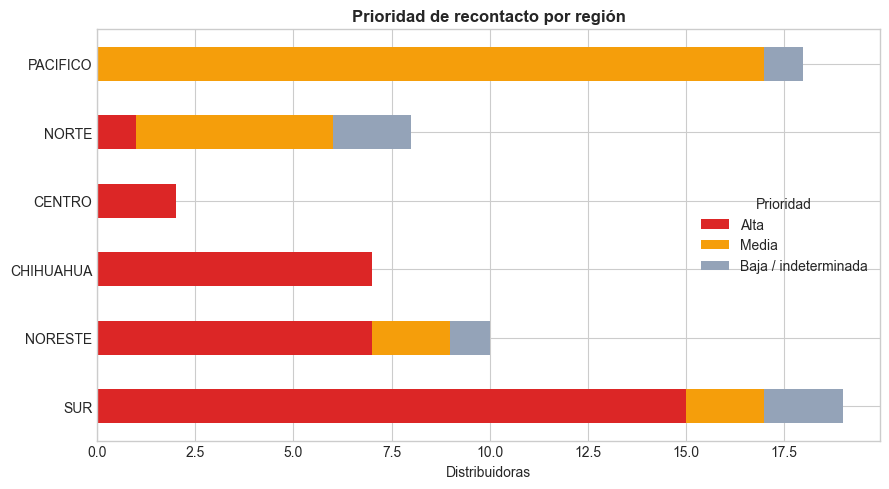

In [18]:
prioridad_region = pd.crosstab(
    segmentos["region"].fillna("Sin región"), segmentos["prioridad"]
)
orden_prioridad = [
    prioridad
    for prioridad in ["Alta", "Media", "Baja / indeterminada"]
    if prioridad in prioridad_region.columns
]
prioridad_region = prioridad_region[orden_prioridad].sort_values(
    orden_prioridad, ascending=False
)

ax = prioridad_region.plot.barh(
    stacked=True,
    figsize=(9, 5),
    color=["#dc2626", "#f59e0b", "#94a3b8"],
)
ax.set_title("Prioridad de recontacto por región", fontweight="bold")
ax.set_xlabel("Distribuidoras")
ax.set_ylabel("")
ax.legend(title="Prioridad", frameon=False)
plt.tight_layout()
plt.show()

## 12. Plan de recontacto

La prioridad alta reúne a quienes declararon disposición de continuar; cuando además reportan competencia, el contacto debe enfocarse en recuperar actividad y entender la oferta alternativa.

In [21]:
conteo_prioridad = segmentos["prioridad"].value_counts()
conteo_region_alta = (
    segmentos[segmentos["prioridad"] == "Alta"]["region"]
    .value_counts()
    .head(3)
)

plan_recontacto = f"""# Plan de recontacto

## Prioridad alta: {conteo_prioridad.get('Alta', 0)} distribuidoras

Contactar primero a quienes respondieron `Sí` o `Tal vez` en disposición. Si también usan otra financiera, preguntar qué condición concreta valoran y ofrecer una respuesta específica.

## Prioridad media: {conteo_prioridad.get('Media', 0)} distribuidoras

Incluye respuestas `No` y casos que reportan competencia sin disposición registrada. El objetivo es entender la causa de salida y documentar condiciones comparables.

## Prioridad baja o indeterminada: {conteo_prioridad.get('Baja / indeterminada', 0)} distribuidoras

No tienen disposición registrada ni una señal suficiente para priorizar. Mantenerlas para una segunda ronda o completar la información.

## Regiones con más casos de prioridad alta

"""
for region, cantidad in conteo_region_alta.items():
    plan_recontacto += f"- {region}: {cantidad}\\n"

plan_recontacto += """
## Guion mínimo sugerido

1. Confirmar si actualmente coloca con otra financiera.
2. Preguntar cuál es la principal barrera: clientes, pagos, atención, disponibilidad o producto digital.
3. Ofrecer una acción concreta y registrar si acepta un siguiente contacto.
4. No tratar los faltantes de P5 como rechazo automático: confirmar la disposición.
"""

ruta_plan = Path("../data/processed/plan_recontacto.md")
ruta_plan.write_text(plan_recontacto, encoding="utf-8")

# Actualizar el reporte ejecutivo con el resultado de la segmentación.
reporte_actualizado = reporte + f"""

## Segmentación de recontacto

- Prioridad alta: {conteo_prioridad.get('Alta', 0)} distribuidoras.
- Prioridad media: {conteo_prioridad.get('Media', 0)} distribuidoras.
- Baja o indeterminada: {conteo_prioridad.get('Baja / indeterminada', 0)} distribuidoras.
- La región con más casos de alta prioridad es {conteo_region_alta.index[0] if len(conteo_region_alta) else 'no disponible'}.

El listado detallado está en `segmentos_recontacto.csv` y el guion operativo en `plan_recontacto.md`.
"""
ruta_reporte.write_text(reporte_actualizado, encoding="utf-8")
print(f"Guardado: {ruta_plan}")
print(f"Actualizado: {ruta_reporte}")

Guardado: ..\data\processed\plan_recontacto.md
Actualizado: ..\data\processed\reporte_ejecutivo_encuestas.md


## 7. Resumen del diagnóstico

- 377 intentos de llamada registrados; sólo **64 (17%)** resultaron en llamada efectiva con encuesta contestada.
- El resto del "nulo" en las columnas de preguntas es esperado (llamada no contestada), no un problema de captura.
- Dentro de las 64 llamadas efectivas, la tasa de respuesta a P1/P2/P3 es alta (>95%); P4/P5 son condicionales por diseño.
- 7 `id_cliente` duplicados en la bitácora de llamadas (revisar si son reintentos de contacto al mismo cliente).
- El cruce con BASE y Hoja2 es prácticamente perfecto (~100% de match), lo que permite enriquecer cada respuesta con región, tipo/nivel de distribuidora, antigüedad y datos de crédito.
- **Implicación para las siguientes etapas:** el análisis de contenido (texto, clustering, sentimiento) sólo tiene una base de **n=64** respuestas. Es una muestra chica para clustering robusto o NLP con muchos temas; hay que ser conservadores en el número de segmentos/temas y complementar con lectura cualitativa directa de las respuestas abiertas.